### Imports

In [62]:
from pathlib import Path
import pandas as pd
import numpy as np

### Paths

In [63]:
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
INTERIM_DIR = REPO_ROOT / "data" / "interim"

GOLD_PATH = PROCESSED_DIR / "gold_nbhd_day_weather_511.parquet"
ADJ_PATH = INTERIM_DIR / "nbhd_adjacency.parquet"

print("GOLD_PATH:", GOLD_PATH)
print("ADJ_PATH:", ADJ_PATH)

GOLD_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\gold_nbhd_day_weather_511.parquet
ADJ_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\nbhd_adjacency.parquet


### Load and canonical naming

In [64]:
df = pd.read_parquet(GOLD_PATH)
adj = pd.read_parquet(ADJ_PATH)

# Standardize to lowercase and remove duplicates immediately
def canonical_naming_and_cleanup(df):
    mapping = {'AREA_NAME': 'area_name', 'AREA_ID': 'area_id', 'Area Name': 'area_name'}
    df = df.rename(columns=mapping)
    # Remove any duplicate columns by keeping only the first instance
    df = df.loc[:, ~df.columns.duplicated()]
    return df

df = canonical_naming_and_cleanup(df)
print("Cleaned shape:", df.shape)
print("Unique columns:", df.columns.is_unique) # Should be True

Cleaned shape: (692514, 26)
Unique columns: True


### Normalize types and sort

In [65]:
df["date"] = pd.to_datetime(df["date"])
df["nbhd_id"] = pd.to_numeric(df["nbhd_id"], errors="coerce").astype(int)

adj["nbhd_id"] = pd.to_numeric(adj["nbhd_id"], errors="coerce").astype(int)
adj["adjacent_nbhd_id"] = pd.to_numeric(adj["adjacent_nbhd_id"], errors="coerce").astype(int)

df = df.sort_values(["nbhd_id", "date"]).reset_index(drop=True)

print(df[["date", "nbhd_id"]].head())

        date  nbhd_id
0 2014-01-01        1
1 2014-01-02        1
2 2014-01-03        1
3 2014-01-04        1
4 2014-01-05        1


### Check required columns

In [66]:
required_cols = [
    "collisions",
    "ksi_collisions",
    "ksi_weighted_score",
    "tavg", "tmin", "tmax", "prcp", "snow", "wspd",
    "freeze_day", "snow_day", "rain_day",
    "road_events_count",
    "road_events_severity_weighted",
    "road_events_full_closure_count",
    "road_construction_count",
    "road_construction_severity_weighted",
    "road_construction_full_closure_count",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("All required columns present.")

All required columns present.


### Build direct lags for collisions, KSI, and 511

In [67]:
group = df.groupby("nbhd_id", group_keys=False)

base_lag_cols = [
    "collisions",
    "ksi_collisions",
    "ksi_weighted_score",
    "road_events_count",
    "road_events_severity_weighted",
    "road_events_full_closure_count",
    "road_construction_count",
    "road_construction_severity_weighted",
    "road_construction_full_closure_count",
]

for col in base_lag_cols:
    for L in [1, 7, 14]:
        df[f"{col}_lag{L}"] = group[col].shift(L)

print("Direct lag features created.")

Direct lag features created.


### Build direct rolling “fatigue” features

In [68]:
rolling_cols = [
    "collisions",
    "ksi_collisions",
    "ksi_weighted_score",
    "road_events_count",
    "road_construction_count",
    "road_events_severity_weighted",
    "road_construction_severity_weighted",
]

for col in rolling_cols:
    df[f"{col}_roll7_sum"]  = group[col].shift(1).rolling(7).sum().reset_index(level=0, drop=True)
    df[f"{col}_roll14_sum"] = group[col].shift(1).rolling(14).sum().reset_index(level=0, drop=True)
    df[f"{col}_roll30_sum"] = group[col].shift(1).rolling(30).sum().reset_index(level=0, drop=True)



print("Direct rolling fatigue features created.")

Direct rolling fatigue features created.


### Build halo features from adjacent neighbourhoods

#### create neighbor-date expansion

In [69]:
road_cols = [
    "road_events_count",
    "road_events_severity_weighted",
    "road_events_full_closure_count",
    "road_construction_count",
    "road_construction_severity_weighted",
    "road_construction_full_closure_count",
]

road_daily = df[["date", "nbhd_id"] + road_cols].copy()

# Link each nbhd_id to adjacent neighbourhood data
halo = adj.merge(
    road_daily,
    left_on="adjacent_nbhd_id",
    right_on="nbhd_id",
    how="left",
    suffixes=("", "_neighbor")
)

print("Halo merged shape:", halo.shape)
halo.head()

Halo merged shape: (3743082, 10)


,nbhd_id,adjacent_nbhd_id,date,nbhd_id_neighbor,road_events_count,road_events_severity_weighted,road_events_full_closure_count,road_construction_count,road_construction_severity_weighted,road_construction_full_closure_count
0,1,3,2014-01-01,3,0,0,0,0,0,0
1,1,3,2014-01-02,3,0,0,0,0,0,0
2,1,3,2014-01-03,3,0,0,0,0,0,0
3,1,3,2014-01-04,3,0,0,0,0,0,0
4,1,3,2014-01-05,3,0,0,0,0,0,0


#### aggregate neighbors’ road activity per date and focal nbhd

In [70]:
halo_daily = (
    halo.groupby(["date", "nbhd_id"], as_index=False)[road_cols]
    .sum()
)

# rename to halo_*
halo_daily = halo_daily.rename(columns={c: f"{c}_halo" for c in road_cols})

print("halo_daily shape:", halo_daily.shape)
halo_daily.head()

halo_daily shape: (692514, 8)


,date,nbhd_id,road_events_count_halo,road_events_severity_weighted_halo,road_events_full_closure_count_halo,road_construction_count_halo,road_construction_severity_weighted_halo,road_construction_full_closure_count_halo
0,2014-01-01,1,0,0,0,0,0,0
1,2014-01-01,2,0,0,0,0,0,0
2,2014-01-01,3,0,0,0,0,0,0
3,2014-01-01,4,0,0,0,0,0,0
4,2014-01-01,5,0,0,0,0,0,0


### Merge halo features back into main table

In [71]:
before_rows = len(df)

df = df.merge(
    halo_daily,
    on=["date", "nbhd_id"],
    how="left"
)

assert len(df) == before_rows, "Row count changed after halo merge"

### Composite & Improvement Features
#Total Zone Pressure (Direct + Halo)
df['road_construction_total_pressure'] = df['road_construction_count'] + df['road_construction_count_halo']

#Rolling version of combined pressure
df['road_construction_total_pressure_roll14_sum'] = (
    df.groupby('nbhd_id')['road_construction_total_pressure']
    .shift(1).rolling(14).sum().reset_index(level=0, drop=True)
)

#Binary "Stability" Indicator
df['is_zone_disrupted'] = (df['road_construction_total_pressure'] > 0).astype(int)
df["is_road_disrupted_halo"] = (df["road_construction_count_halo"] > 0).astype(int)

#Normalization (Log Squashing) for ANN Stability
df['road_construction_total_pressure_norm'] = np.log1p(df['road_construction_total_pressure'])
df["road_construction_count_halo_norm"] = np.log1p(df["road_construction_count_halo"])
df["road_construction_severity_halo_norm"] = np.log1p(df["road_construction_severity_weighted_halo"])

print("Composite, Binary, and Normalized features successfully created.")

halo_cols = [c for c in df.columns if c.endswith("_halo")]
for c in halo_cols:
    df[c] = df[c].fillna(0).astype(int)

print("Halo features merged.")
df[["date", "nbhd_id"] + halo_cols[:4]].head()

Composite, Binary, and Normalized features successfully created.
Halo features merged.


,date,nbhd_id,road_events_count_halo,road_events_severity_weighted_halo,road_events_full_closure_count_halo,road_construction_count_halo
0,2014-01-01,1,0,0,0,0
1,2014-01-02,1,0,0,0,0
2,2014-01-03,1,0,0,0,0
3,2014-01-04,1,0,0,0,0
4,2014-01-05,1,0,0,0,0


### Build lag/rolling features for halo road signals

In [72]:
halo_road_cols = [
    "road_events_count_halo",
    "road_events_severity_weighted_halo",
    "road_events_full_closure_count_halo",
    "road_construction_count_halo",
    "road_construction_severity_weighted_halo",
    "road_construction_full_closure_count_halo",
]

group = df.groupby("nbhd_id", group_keys=False)

for col in halo_road_cols:
    for L in [1, 7]:
        df[f"{col}_lag{L}"] = group[col].shift(L)

    df[f"{col}_roll7_sum"]  = group[col].shift(1).rolling(7).sum().reset_index(level=0, drop=True)
    df[f"{col}_roll14_sum"] = group[col].shift(1).rolling(14).sum().reset_index(level=0, drop=True)

print("Halo lag/rolling features created.")

Halo lag/rolling features created.


### Add calendar features

In [73]:
df["dow"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

print(df[["date", "dow", "month", "year"]].head())

        date  dow  month  year
0 2014-01-01    2      1  2014
1 2014-01-02    3      1  2014
2 2014-01-03    4      1  2014
3 2014-01-04    5      1  2014
4 2014-01-05    6      1  2014


### Drop rows with lag-related NaNs

In [74]:
minimum_needed = [
    "collisions_lag1",
    "collisions_roll7_sum",
    "road_construction_count_lag1",
    "road_construction_count_halo_lag1",
]

missing_needed = [c for c in minimum_needed if c not in df.columns]
if missing_needed:
    raise ValueError(f"Expected lag columns missing: {missing_needed}")

df_model = df.dropna(subset=["collisions_lag1", "collisions_roll7_sum"]).copy()

print("Original shape:", df.shape)
print("Model-ready shape:", df_model.shape)

Original shape: (692514, 114)
Model-ready shape: (691408, 114)


### Quick signal checks

In [75]:
signal_cols = [
    "road_construction_count",
    "road_construction_count_halo",
    "road_construction_count_roll14_sum",
    "road_construction_count_halo_roll14_sum",
]

for c in signal_cols:
    if c in df_model.columns:
        print(c, "non-zero rows:", (df_model[c] > 0).sum())

road_construction_count non-zero rows: 2325
road_construction_count_halo non-zero rows: 9951
road_construction_count_roll14_sum non-zero rows: 2345
road_construction_count_halo_roll14_sum non-zero rows: 10032


### Improvements: Normalization & Binary Indicators

In [76]:
#create binary indicators (stable signals for the model)
#If there is any construction nearby, it's often more predictive than the exact count
df_model["is_road_disrupted_halo"] = (df_model["road_construction_count_halo"] > 0).astype(int)

#Normalization to prevent halo sums from dominating weights
#we use a simple Log(1+x) transformation to squash large halo counts
df_model["road_construction_count_halo_norm"] = np.log1p(df_model["road_construction_count_halo"])
df_model["road_construction_severity_halo_norm"] = np.log1p(df_model["road_construction_severity_weighted_halo"])

print("Binary indicator and normalized halo features added.")
print(df_model[["road_construction_count_halo", "road_construction_count_halo_norm", "is_road_disrupted_halo"]].tail())

Binary indicator and normalized halo features added.
        road_construction_count_halo  road_construction_count_halo_norm  \
692509                             0                                0.0   
692510                             0                                0.0   
692511                             0                                0.0   
692512                             0                                0.0   
692513                             0                                0.0   

        is_road_disrupted_halo  
692509                       0  
692510                       0  
692511                       0  
692512                       0  
692513                       0  


### save

In [77]:
out_path = PROCESSED_DIR / "features_nbhd_day_511.parquet"
df_model.to_parquet(out_path, index=False)

print("Saved:", out_path)

Saved: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\features_nbhd_day_511.parquet


### Visual Validation

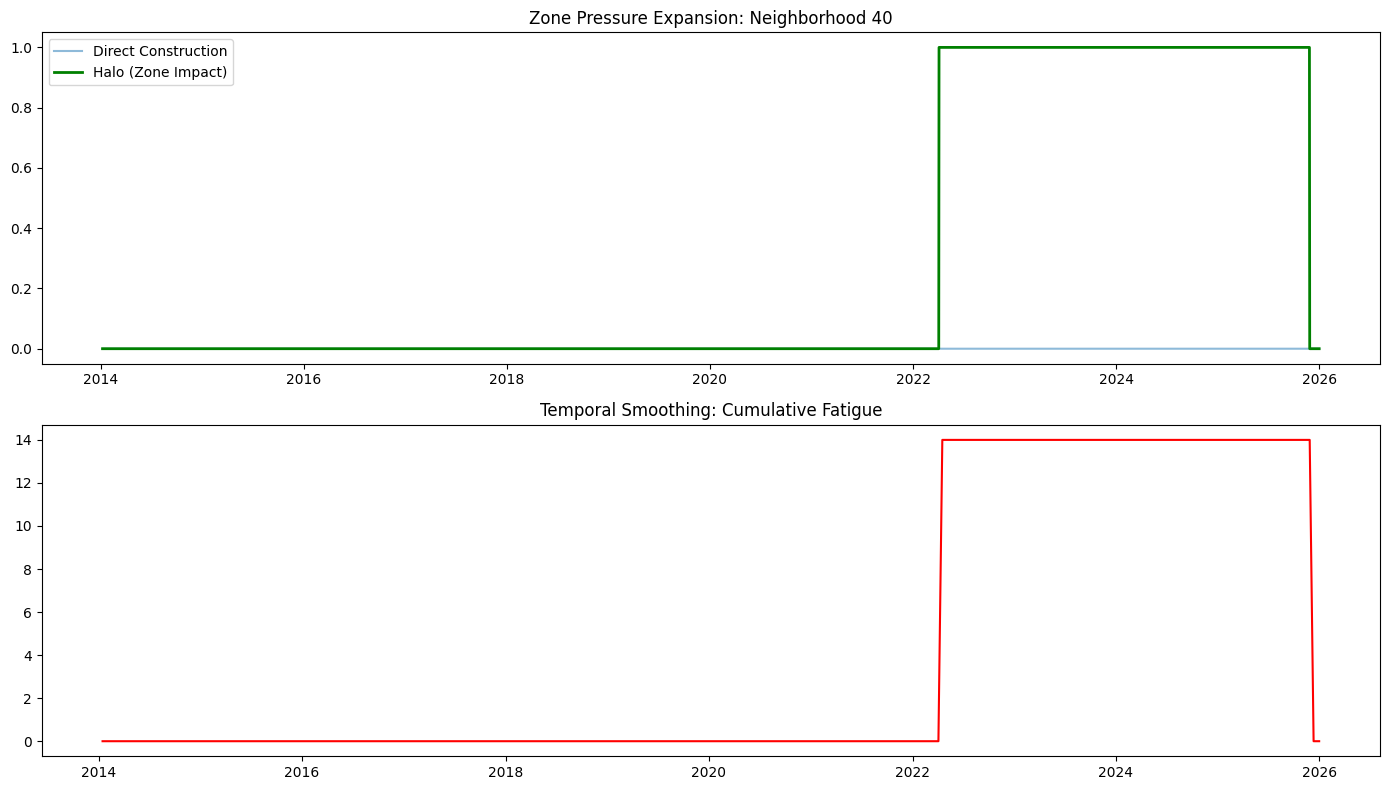

In [78]:
# FIND THE BEST NEIGHBORHOOD TO DEMONSTRATE HALO
# We want one where neighbors have construction but the center neighborhood might not
strong_halo_candidate = df_model[
    (df_model['road_construction_count_halo'] > df_model['road_construction_count'])
].groupby('nbhd_id').size().idxmax()

sample_nbhd = strong_halo_candidate
df_plot = df_model[df_model['nbhd_id'] == sample_nbhd].sort_values('date')

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(df_plot['date'], df_plot['road_construction_count'], label='Direct Construction', alpha=0.5)
plt.plot(df_plot['date'], df_plot['road_construction_count_halo'], label='Halo (Zone Impact)', linewidth=2, color='green')
plt.title(f'Zone Pressure Expansion: Neighborhood {sample_nbhd}')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df_plot['date'], df_plot['road_construction_count_halo_roll14_sum'], label='14-Day Fatigue', color='red')
plt.title('Temporal Smoothing: Cumulative Fatigue')
plt.tight_layout()
plt.show()